# NOTE: This notebook uses local fallback paths for exploratory analysis.
# Production pipeline runs via run_pipeline.py or the Airflow DAG.

# Stage 1a — Ingest: Census Block Population Data

This notebook explores the **Census 2020 Decennial (PL 94-171)** block-level population data for Washington DC.

The pipeline fetches this via the Census REST API, with a local shapefile fallback.

**Key outputs:**
- 6,012 census blocks with population counts
- Geometry in EPSG:26985 (Maryland State Plane, metres)

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

Blocks_DC = "../data/intermediate_files/blocks_Washington_DC.shp"
CRS = "EPSG:26985"  # Maryland State Plane NAD83
STUDY_AREA = "Washington, DC"
print(f"Study area : {STUDY_AREA}")
print(f"CRS        : {CRS}")
print(f"Shapefile  : {Blocks_DC}")

Study area : Washington, DC
CRS        : EPSG:26985
Shapefile  : ../data/intermediate_files/blocks_Washington_DC.shp


## 1. Load Raw Data (local shapefile)

We load the DC census blocks shapefile directly to understand the raw schema before any pipeline processing.

In [3]:
raw_Blocks_DC = gpd.read_file("../data/intermediate_files/blocks_Washington_DC.shp")
print(f"Shape     : {raw_Blocks_DC.shape}")
print(f"CRS       : {raw_Blocks_DC.crs}")
print(f"\nColumns:\n{list(raw_Blocks_DC.columns)}")

Shape     : (6012, 25)
CRS       : EPSG:26985

Columns:
['OBJECTID', 'BLKGRP', 'BLOCK', 'GEOID_left', 'Bl_totpop', 'TRACT', 'GEOCODE', 'STATE', 'Longitude', 'Latitude', 'Total Popu', 'Total Po_1', 'Total Po_2', 'Total po_3', 'eighteento', '65 years a', 'TotalPopul', 'Bl_incomep', 'Bl_healthi', 'pop_weight', 'PerCapInc', 'HI_blk', 'age_18_65', 'accessibil', 'geometry']


In [4]:
raw_Blocks_DC.head(3)

,OBJECTID,BLKGRP,BLOCK,GEOID_left,Bl_totpop,TRACT,GEOCODE,STATE,Longitude,Latitude,...,65 years a,TotalPopul,Bl_incomep,Bl_healthi,pop_weight,PerCapInc,HI_blk,age_18_65,accessibil,geometry
0,1,1,1004,7500000US110010001021004,0.019941,000102,110010001021004,11,-77.061272,38.905555,...,857,-0.077246,168461.0,3127.0,0.018686,0.038399,0.016381,0.013093,1396.196206,"POLYGON ((394049.812 138798.76, 394109.244 138..."
1,2,1,1006,7500000US110010001021006,0.086303,000102,110010001021006,11,-77.061272,38.905555,...,857,-0.077246,168461.0,3127.0,0.079867,0.164125,0.070017,0.056719,1149.542398,"POLYGON ((394813.175 138308.122, 394906 138617..."
2,3,1,1001,7500000US110010001021001,0.019941,000102,110010001021001,11,-77.061272,38.905555,...,857,-0.077246,168461.0,3127.0,0.018686,0.038399,0.016381,0.013093,1774.968524,"POLYGON ((394162.164 138977.622, 394167.541 13..."


## 2. Column Inspection — Identifying the Population Column

Several population-related columns exist. We check which has meaningful integer-scale values.

In [5]:
pop_candidates = ["Bl_totpop", "TotalPopul", "Total Popu", "Total Po_1", "pop_weight"]

summary = []
for col in pop_candidates:
    if col in raw_Blocks_DC.columns:
        s = raw_Blocks_DC[col].describe()
        summary.append({
            "column"  : col,
            "dtype"   : str(raw_Blocks_DC[col].dtype),
            "min"     : round(s["min"], 4),
            "max"     : round(s["max"], 4),
            "mean"    : round(s["mean"], 4),
            "nonzero" : int((raw_Blocks_DC[col] > 0).sum()),
        })

pd.DataFrame(summary)

,column,dtype,min,max,mean,nonzero
0,Bl_totpop,float64,0.0000,1.0000,0.0423,6009
1,TotalPopul,float64,-2.9253,3.7247,0.1684,3334
2,Total Popu,int64,13.0000,7730.0000,3603.1055,6012
3,Total Po_1,int64,13.0000,4319.0000,1716.4150,6012
4,pop_weight,float64,0.0002,4.7692,0.1892,6012


`Total Popu` holds the actual integer population counts — all 6,012 blocks have values > 0.  
`Bl_totpop` contains fractional weights (0–1), not raw counts.  
`GEOCODE` is the full 15-digit block FIPS code used as the unique block identifier.

## 3. Prepare Analysis-Ready GeoDataFrame

In [12]:
# Build a clean GeoDataFrame directly from the raw shapefile
pop_gdf = raw_Blocks_DC[["geometry", "GEOCODE", "Total Popu"]].copy()
pop_gdf = pop_gdf.rename(columns={"GEOCODE": "GEOID", "Total Popu": "population"})
pop_gdf["population"] = pop_gdf["population"].fillna(0).astype(int)
pop_gdf = pop_gdf.to_crs(CRS)

print(f"Rows     : {len(pop_gdf):,}")
print(f"Columns  : {list(pop_gdf.columns)}")
print(f"CRS      : {pop_gdf.crs}")
print(f"\nNull counts:\n{pop_gdf.isnull().sum()}")

Rows     : 6,012
Columns  : ['geometry', 'GEOID', 'population']
CRS      : EPSG:26985

Null counts:
geometry      0
GEOID         0
population    0
dtype: int64


## 4. Population Distribution

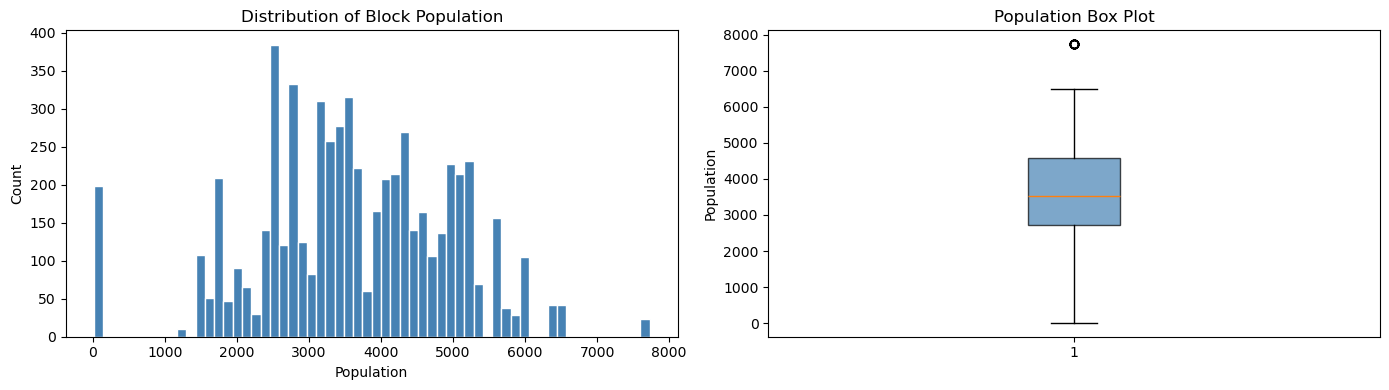


Total DC population : 21,661,870
Zero-pop blocks     : 0
Max block pop       : 7,730


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pop_gdf["population"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Block Population")
axes[0].set_xlabel("Population")
axes[0].set_ylabel("Count")

axes[1].boxplot(pop_gdf["population"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Population Box Plot")
axes[1].set_ylabel("Population")

plt.tight_layout()
plt.savefig("../outputs/figures/eda_01_population_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal DC population : {pop_gdf['population'].sum():,}")
print(f"Zero-pop blocks     : {(pop_gdf['population'] == 0).sum()}")
print(f"Max block pop       : {pop_gdf['population'].max():,}")

## 5. Spatial Map — Population by Census Block

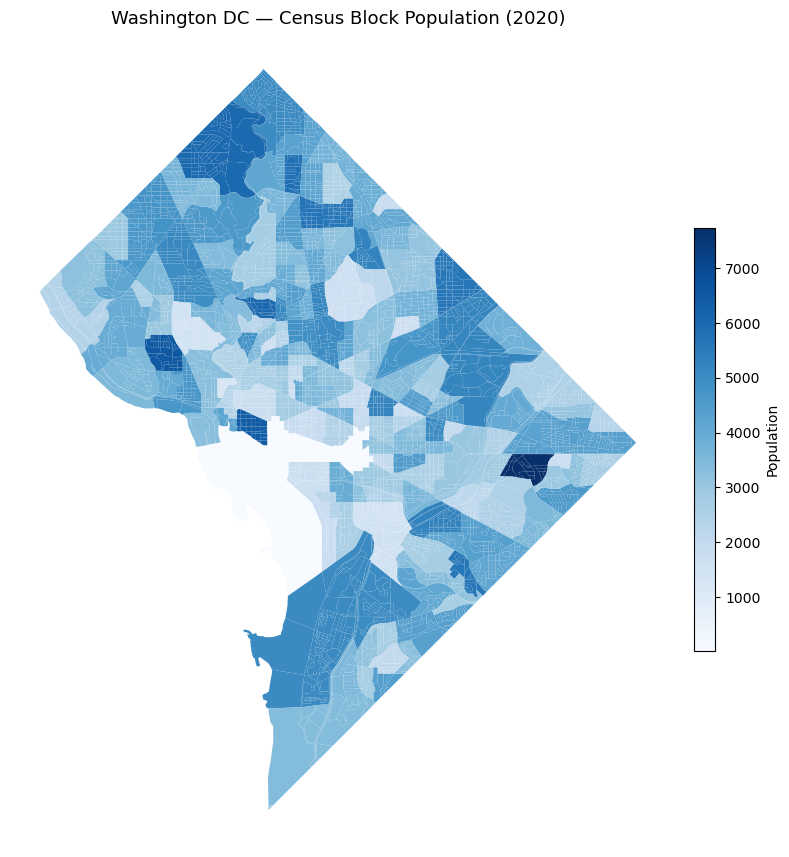

In [10]:
fig, ax = plt.subplots(figsize=(8, 9))

pop_gdf.plot(
    column="population",
    ax=ax,
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Population", "fraction": 0.03, "pad": 0.04},
    linewidth=0,
)
ax.set_title("Washington DC — Census Block Population (2020)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/figures/eda_01_population_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Key Stats Summary

In [11]:
stats = pop_gdf["population"].describe().rename("Population Stats")
stats["total"] = pop_gdf["population"].sum()
stats["zero_blocks"] = (pop_gdf["population"] == 0).sum()
stats["zero_pct"] = f"{(pop_gdf['population'] == 0).mean()*100:.1f}%"
print(stats.to_string())

count               6012.0
mean           3603.105456
std            1350.537625
min                   13.0
25%                 2733.0
50%                 3527.0
75%                 4567.0
max                 7730.0
total           21661870.0
zero_blocks            0.0
zero_pct              0.0%
